<a href="https://colab.research.google.com/github/annagiacometti/cultural-data-framework-photography-festivals/blob/main/dataset_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisi esplorativa del dataset dei festival fotografici italiani


Notebook sviluppato nell'ambito della tesi di Laurea Magistrale:

"Dalla frammentazione alla strutturazione del dato culturale: sviluppo di un framework metodologico e sperimentazione di strumenti basati su intelligenza artificiale. Il caso dei festival fotografici italiani"

---

Anna Giacometti

Università degli Studi di Palermo -
Corso di Laurea Magistrale in Digital Humanities per l'Industria Culturale

#1. Importazione librerie e configurazione ambiente

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!git clone https://github.com/annagiacometti/cultural-data-framework-photography-festivals.git

BASE_PATH = "cultural-data-framework-photography-festivals"
DATASET_PATH = f"{BASE_PATH}/dataset/dataset_italian_photography_festivals_2026_snapshot_8-8-26.xlsx"


Cloning into 'cultural-data-framework-photography-festivals'...
remote: Enumerating objects: 255, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 255 (delta 19), reused 0 (delta 0), pack-reused 187 (from 1)
Receiving objects: 100% (255/255), 3.53 MiB | 14.76 MiB/s, done.
Resolving deltas: 100% (69/69), done.


#2. Caricamento dataset

In [ ]:
df = pd.read_excel(
    DATASET_PATH,
    header=1
)

df.columns = df.columns.str.strip()
df = df.replace("null", pd.NA)
df = df.dropna(
    subset=["festival_name"]
).reset_index(drop=True)

display(df.head())

,festival_id,festival_name,city_name,city_geonames_id,region,region_nuts,country_iso,first_edition_year,festival_status,duration_days,...,has_books_press,has_heritage,has_architecture_design,has_performing_arts,has_audiovisual_multimedia,venue_type,ticket_policy,sustainability_claim,notes,record_last_updated
0,FEST000002,ANALOGICA,Bolzano,3181913.0,Trentino-Alto Adige/Südtirol,ITH1,IT,2011,active,5,...,0.0,1.0,0.0,1.0,1.0,cultural_space,unknown,0.0,NaN,2026-07-24
1,FEST000003,Milano Centrale Festival,Milano,6951411.0,Lombardia,ITC4,IT,2023,active,3,...,1.0,0.0,0.0,1.0,1.0,mixed,free,0.0,NaN,2026-07-24
2,FEST000004,Fano Centrale Festival,Fano,3177219.0,Marche,ITI3,IT,2009,active,7,...,1.0,0.0,0.0,0.0,1.0,mixed,free,0.0,NaN,2026-07-24
3,FEST000005,Festival della Fotografia Etica,Lodi,3174638.0,Lombardia,ITC4,IT,2010,active,30,...,1.0,0.0,0.0,0.0,1.0,mixed,paid,1.0,NaN,2026-07-24
4,FEST000006,Siena Awards Photo Festival,Siena,3166548.0,Toscana,ITI1,IT,2015,active,51,...,1.0,0.0,0.0,0.0,0.0,mixed,paid,0.0,NaN,2026-07-24


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   festival_id                    102 non-null    object        
 1   festival_name                  102 non-null    object        
 2   city_name                      102 non-null    object        
 3   city_geonames_id               102 non-null    float64       
 4   region                         102 non-null    object        
 5   region_nuts                    102 non-null    object        
 6   country_iso                    102 non-null    object        
 7   first_edition_year             102 non-null    object        
 8   festival_status                102 non-null    object        
 9   duration_days                  102 non-null    object        
 10  recurrence                     102 non-null    object        
 11  website_official   

# 3. Analisi descrittiva del campione

##3.1 Distribuzione territoriale e prima edizione

###3.1.1 Numero festival

In [ ]:
df["festival_name"].nunique()

102

###3.1.2 Distribuzione regionale

In [ ]:

region_counts = (
    df["region"]
    .value_counts(dropna=False)
)

display(region_counts)

,count
region,
Lombardia,17
Lazio,10
Emilia-Romagna,9
Marche,8
Toscana,7
Veneto,7
Sardegna,5
Puglia,5
Piemonte,5


In [ ]:
region_percent = (
    df["region"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(1)
)

display(region_percent)

,proportion
region,
Lombardia,16.7
Lazio,9.8
Emilia-Romagna,8.8
Marche,7.8
Toscana,6.9
Veneto,6.9
Sardegna,4.9
Puglia,4.9
Piemonte,4.9


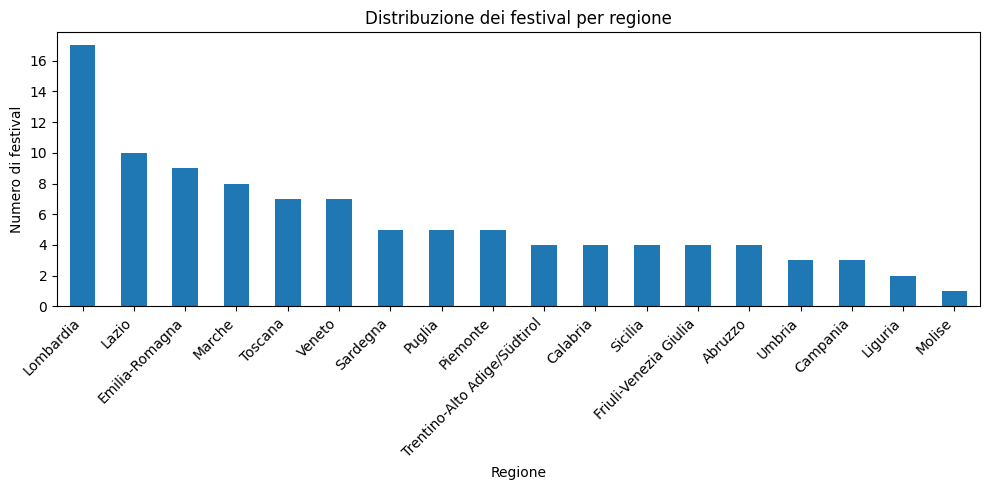

In [ ]:
plt.figure(figsize=(10, 5))

region_counts.dropna().plot(
    kind="bar"
)

plt.xlabel("Regione")
plt.ylabel("Numero di festival")
plt.title("Distribuzione dei festival per regione")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 3.1.3 Anno della prima edizione

In [ ]:
df["first_edition_year"] = pd.to_numeric(
    df["first_edition_year"],
    errors="coerce"
)

df["first_edition_year"].describe()

,first_edition_year
count,98.000000
mean,2017.285714
std,6.811149
min,1992.000000
25%,2013.250000
50%,2018.000000
75%,2022.000000
max,2026.000000


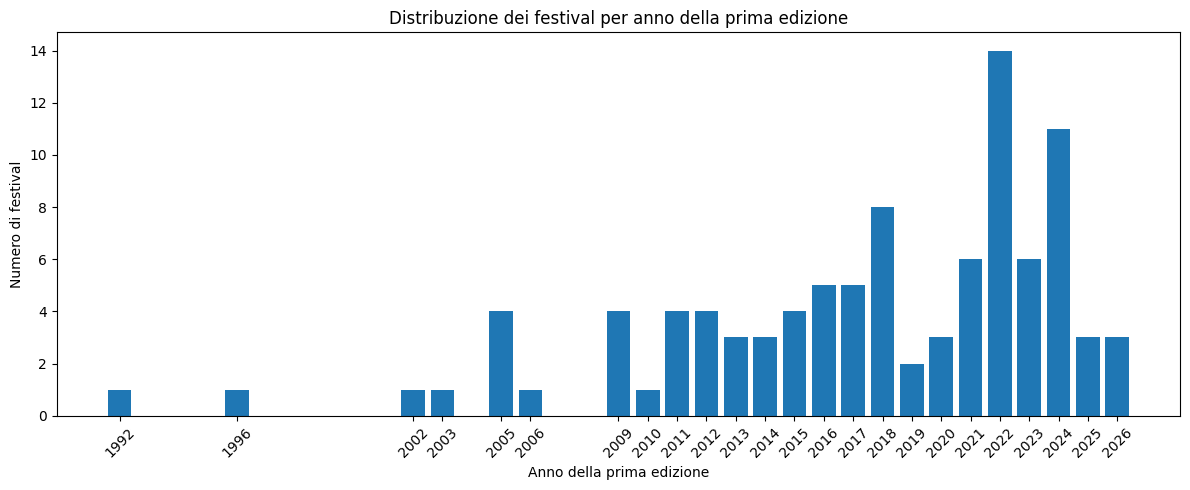

In [ ]:
year_counts = (
    df["first_edition_year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

plt.bar(
    year_counts.index,
    year_counts.values
)

plt.xlabel("Anno della prima edizione")
plt.ylabel("Numero di festival")
plt.title("Distribuzione dei festival per anno della prima edizione")

plt.xticks(
    year_counts.index,
    rotation=45
)

plt.tight_layout()
plt.show()

### 3.1.4 Stato del festival

In [ ]:

summary_status = (
    df["festival_status"]
    .value_counts(dropna=False)
    .rename_axis("festival_status")
    .reset_index(name="count")
)

summary_status["percentage"] = (
    summary_status["count"] / len(df) * 100
).round(1)

display(summary_status)

,festival_status,count,percentage
0,active,72,70.6
1,inactive,27,26.5
2,defunct,3,2.9


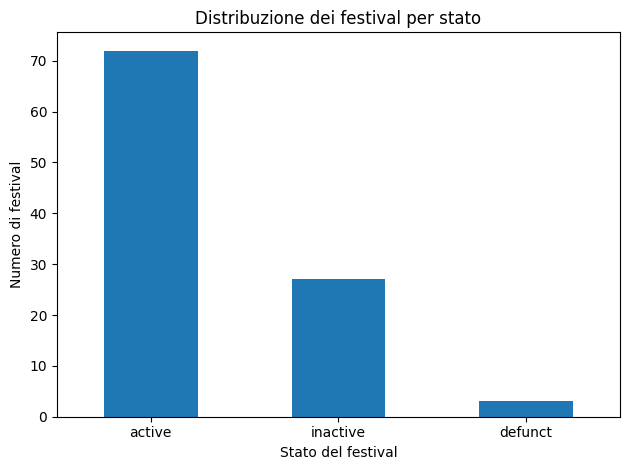

In [ ]:
df["festival_status"].value_counts().plot(
    kind="bar"
)

plt.title("Distribuzione dei festival per stato")
plt.xlabel("Stato del festival")
plt.ylabel("Numero di festival")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##3.2 Caratteristiche organizzative

###3.2.1 Tipologia di organizzatore

In [ ]:
organizer_counts = (
    df["organizer_type"]
    .value_counts(dropna=False)
)

display(organizer_counts)

,count
organizer_type,
non-profit,86
private,7
mixed,6
public,3


In [ ]:
organizer_percent = (
    df["organizer_type"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(1)
)

display(organizer_percent)

,proportion
organizer_type,
non-profit,84.3
private,6.9
mixed,5.9
public,2.9


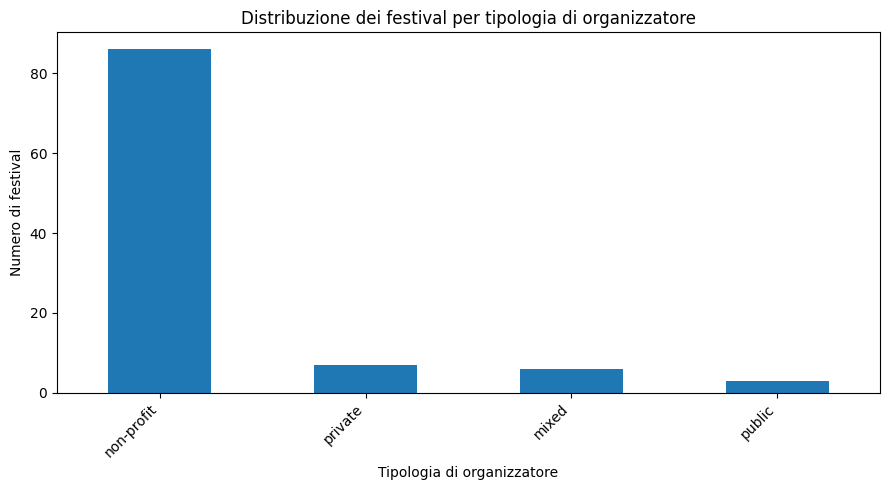

In [ ]:
plt.figure(figsize=(9, 5))

organizer_counts.dropna().plot(
    kind="bar"
)

plt.xlabel("Tipologia di organizzatore")
plt.ylabel("Numero di festival")
plt.title("Distribuzione dei festival per tipologia di organizzatore")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

###3.2.2 Presenza di finanziamenti pubblici documentati

In [ ]:
funding_counts = (
    df["has_documented_public_funding"]
    .value_counts(dropna=False)
)

display(funding_counts)

,count
has_documented_public_funding,
1.0,61
0.0,40
NaN,1


In [ ]:
funding_percent = (
    df["has_documented_public_funding"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(1)
)

display(funding_percent)

,proportion
has_documented_public_funding,
1.0,59.8
0.0,39.2
NaN,1.0


## 3.3 Domini culturali e multidisciplinarità

In [ ]:
domains = [
    "has_photography",
    "has_other_visual_arts",
    "has_books_press",
    "has_architecture_design",
    "has_performing_arts",
    "has_audiovisual_multimedia"
]

domain_counts = (
    df[domains]
    .sum()
    .sort_values(ascending=False)
)

display(domain_counts)

,0
has_photography,102.0
has_books_press,72.0
has_audiovisual_multimedia,58.0
has_other_visual_arts,32.0
has_performing_arts,26.0
has_architecture_design,12.0


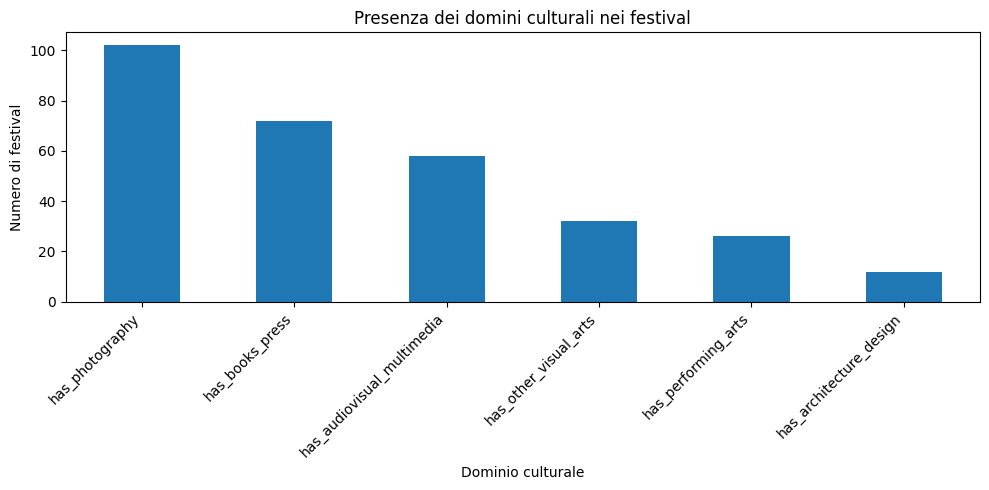

In [ ]:
plt.figure(figsize=(10, 5))

domain_counts.plot(
    kind="bar"
)

plt.xlabel("Dominio culturale")
plt.ylabel("Numero di festival")
plt.title("Presenza dei domini culturali nei festival")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
df["cultural_domains_count"] = df[domains].sum(axis=1)
df["cultural_domains_count"].value_counts().sort_index()

,count
cultural_domains_count,
1.0,11
2.0,29
3.0,33
4.0,14
5.0,12
6.0,3


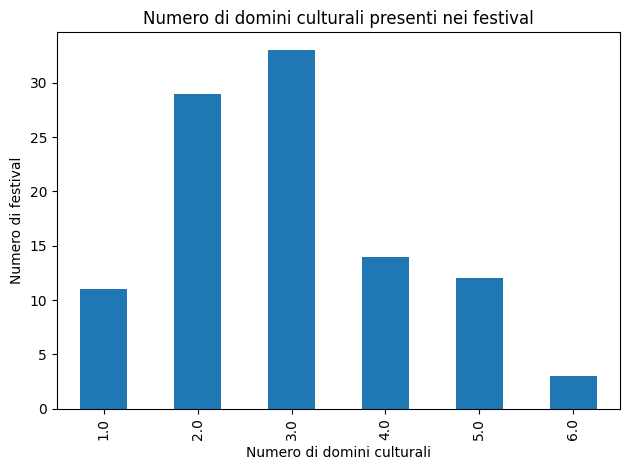

In [ ]:
df["cultural_domains_count"].value_counts().sort_index().plot(
    kind="bar"
)

plt.xlabel("Numero di domini culturali")
plt.ylabel("Numero di festival")
plt.title("Numero di domini culturali presenti nei festival")

plt.tight_layout()
plt.show()

##3.4 Presenza digitale

In [ ]:
# Presenza di un sito web ufficiale: valore non nullo e non vuoto
has_website = (
    df["website_official"].notna() &
    df["website_official"].astype(str).str.strip().ne("")
)

website_official_present = has_website.sum()
website_official_missing = (~has_website).sum()

print(f"Sito web ufficiale presente: {website_official_present} festival ({website_official_present / len(df) * 100:.1f}%)")
print(f"Sito web ufficiale non rilevato: {website_official_missing} festival ({website_official_missing / len(df) * 100:.1f}%)")

Sito web ufficiale presente: 78 festival (76.5%)
Sito web ufficiale non rilevato: 24 festival (23.5%)


In [ ]:
#presenza sito web ufficiale attivo
df["website_active"].value_counts()



,count
website_active,
1.0,57
0.0,45


In [ ]:
# Presenza sui social media
has_instagram = (
    df["instagram"].notna() &
    df["instagram"].astype(str).str.strip().ne("")
)

has_facebook = (
    df["facebook"].notna() &
    df["facebook"].astype(str).str.strip().ne("")
)

instagram_count = has_instagram.sum()
facebook_count = has_facebook.sum()
total = len(df)

print(f"Instagram: {instagram_count} festival ({instagram_count / total * 100:.1f}%)")
print(f"Facebook: {facebook_count} festival ({facebook_count / total * 100:.1f}%)")

Instagram: 82 festival (80.4%)
Facebook: 80 festival (78.4%)


In [ ]:
# Distribuzione delle lingue del sito web
language_counts = df["website_languages"].value_counts(dropna=False)

language_percentages = df["website_languages"].value_counts(normalize=True, dropna=False) * 100

language_distribution = pd.DataFrame({
    "Festival": language_counts,
    "Percentuale": language_percentages.round(1)
})

display(language_distribution)

,Festival,Percentuale
website_languages,,
IT_ONLY,61,59.8
IT_EN,38,37.3
MULTI,3,2.9


In [ ]:
df["digital_presence_score"].describe()

,digital_presence_score
count,102.000000
mean,6.352941
std,2.899802
min,0.000000
25%,4.000000
50%,8.000000
75%,8.750000
max,10.000000


In [ ]:
digital_counts = (
    df["digital_presence_score"]
    .value_counts(dropna=False)
    .sort_index()
)

display(digital_counts)

,count
digital_presence_score,
0.0,7
1.0,3
2.0,7
3.0,1
4.0,11
6.0,9
7.0,10
8.0,28
9.0,24


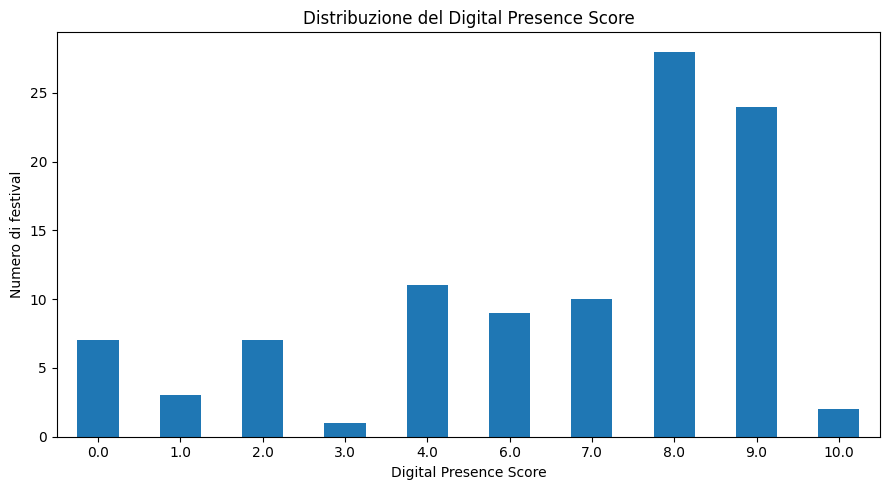

In [ ]:
plt.figure(figsize=(9, 5))

digital_counts.dropna().plot(
    kind="bar"
)

plt.xlabel("Digital Presence Score")
plt.ylabel("Numero di festival")
plt.title("Distribuzione del Digital Presence Score")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

##3.5 Accessibilità e caratteristiche operative

###3.5.1 Politiche di accesso

In [ ]:
ticket_counts = (
    df["ticket_policy"]
    .value_counts(dropna=False)
)

display(ticket_counts)

,count
ticket_policy,
free,49
paid,20
unknown,19
mixed,14


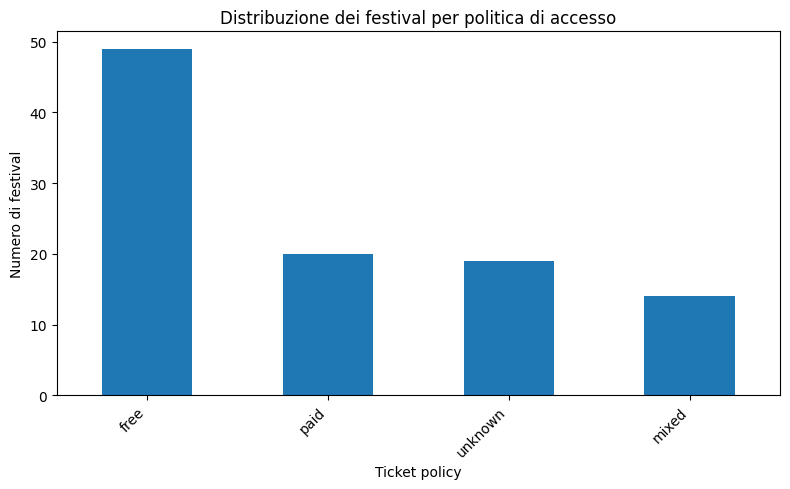

In [ ]:
plt.figure(figsize=(8, 5))

ticket_counts.dropna().plot(
    kind="bar"
)

plt.xlabel("Ticket policy")
plt.ylabel("Numero di festival")
plt.title("Distribuzione dei festival per politica di accesso")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

###3.5.2 Tipologia di venue


In [ ]:
venue_counts = (
    df["venue_type"]
    .value_counts(dropna=False)
)

display(venue_counts)

,count
venue_type,
mixed,52
historic_site,17
cultural_space,16
public_space,12
museum_gallery,5


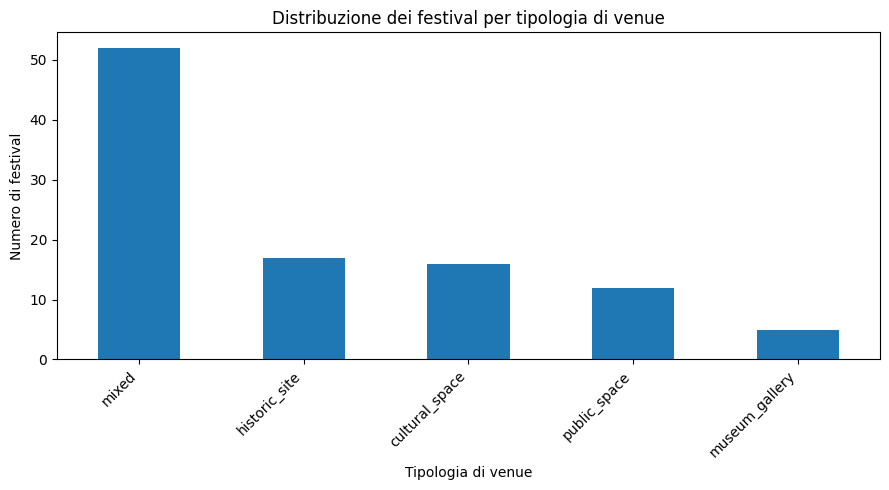

In [ ]:
plt.figure(figsize=(9, 5))

venue_counts.dropna().plot(
    kind="bar"
)

plt.xlabel("Tipologia di venue")
plt.ylabel("Numero di festival")
plt.title("Distribuzione dei festival per tipologia di venue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 3.5.3 Durata dei festival

In [ ]:
df["duration_days"] = pd.to_numeric(
    df["duration_days"],
    errors="coerce"
)

display(
    df["duration_days"].describe()
)

,duration_days
count,98.000000
mean,25.448980
std,30.903949
min,2.000000
25%,4.000000
50%,10.000000
75%,32.750000
max,156.000000


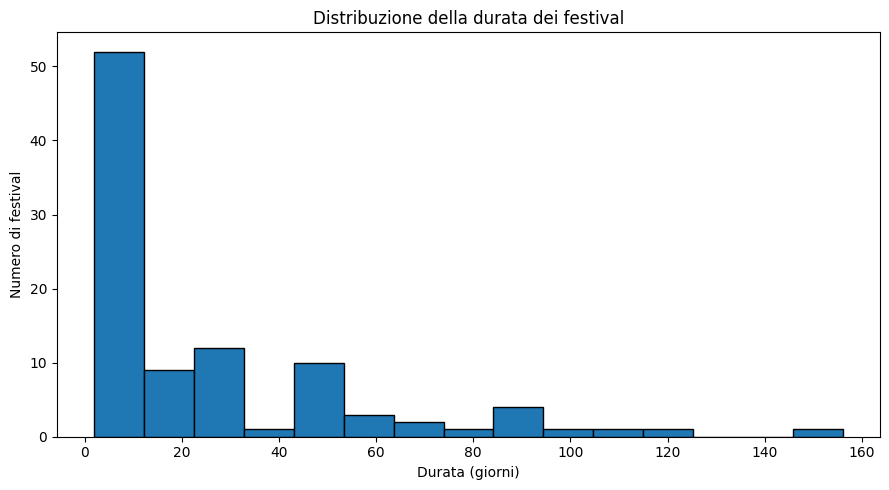

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["duration_days"].dropna(),
    bins=15,
    edgecolor="black"
)

plt.xlabel("Durata (giorni)")
plt.ylabel("Numero di festival")
plt.title("Distribuzione della durata dei festival")

plt.tight_layout()
plt.show()

### 3.5.4 Ricorrenza dei festival

In [ ]:
recurrence_counts = (
    df["recurrence"]
    .value_counts(dropna=False)
)

display(recurrence_counts)

,count
recurrence,
annual,84
biennial,9
unknown,8
mixed,1


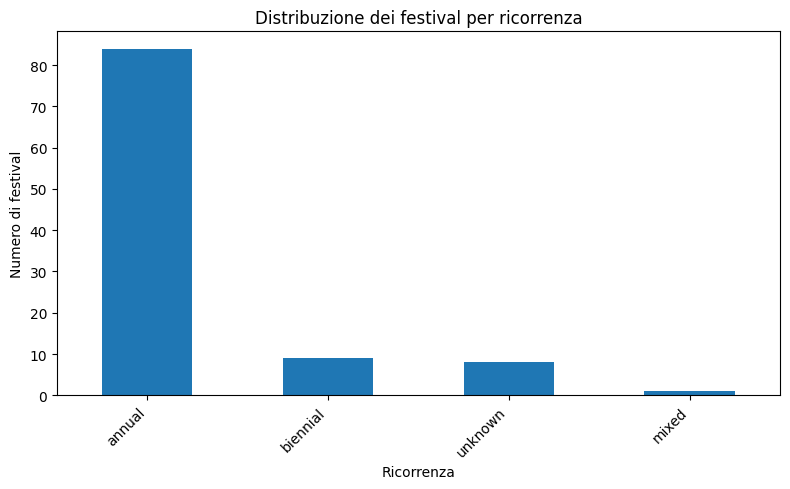

In [ ]:
plt.figure(figsize=(8, 5))

recurrence_counts.dropna().plot(
    kind="bar"
)

plt.xlabel("Ricorrenza")
plt.ylabel("Numero di festival")
plt.title("Distribuzione dei festival per ricorrenza")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 3.6 Apertura internazionale e sostenibilità

In [ ]:
international_vars = [
    "has_international_call",
    "has_international_partners"
]

international_counts = df[international_vars].sum()

display(international_counts)

,0
has_international_call,48.0
has_international_partners,40.0


In [ ]:
website_language_counts = (
    df["website_languages"]
    .value_counts(dropna=False)
)

display(website_language_counts)

,count
website_languages,
IT_ONLY,61
IT_EN,38
MULTI,3


In [ ]:
sustainability_counts = (
    df["sustainability_claim"]
    .value_counts(dropna=False)
)

display(sustainability_counts)

,count
sustainability_claim,
0.0,83
1.0,19


# 4. Analisi esplorativa delle relazioni tra le dimensioni

 ## 4.1 Costruzione delle variabili derivate

In [ ]:
#longevità del festival
df["first_edition_year"] = pd.to_numeric(df["first_edition_year"], errors="coerce")

df["festival_longevity"] = (
    2026 - df["first_edition_year"] +1
)

display(
    df[
        ["festival_name", "first_edition_year", "festival_longevity"]
    ].head()
)

,festival_name,first_edition_year,festival_longevity
0,ANALOGICA,2011.0,16.0
1,Milano Centrale Festival,2023.0,4.0
2,Fano Centrale Festival,2009.0,18.0
3,Festival della Fotografia Etica,2010.0,17.0
4,Siena Awards Photo Festival,2015.0,12.0


In [ ]:
#numero di domini culturali complementari (non calcolando has_photography)
secondary_domains = [
    "has_other_visual_arts",
    "has_books_press",
    "has_architecture_design",
    "has_performing_arts",
    "has_audiovisual_multimedia"
]

df["cross_domain_count"] = (
    df[secondary_domains]
    .fillna(0)
    .sum(axis=1)
)

display(
    df[
        ["festival_name", "cross_domain_count"]
    ].head()
)

,festival_name,cross_domain_count
0,ANALOGICA,2.0
1,Milano Centrale Festival,4.0
2,Fano Centrale Festival,3.0
3,Festival della Fotografia Etica,2.0
4,Siena Awards Photo Festival,1.0


,cross_domain_count,festival,percentuale
0,0.0,11,10.8
1,1.0,29,28.4
2,2.0,33,32.4
3,3.0,14,13.7
4,4.0,12,11.8
5,5.0,3,2.9


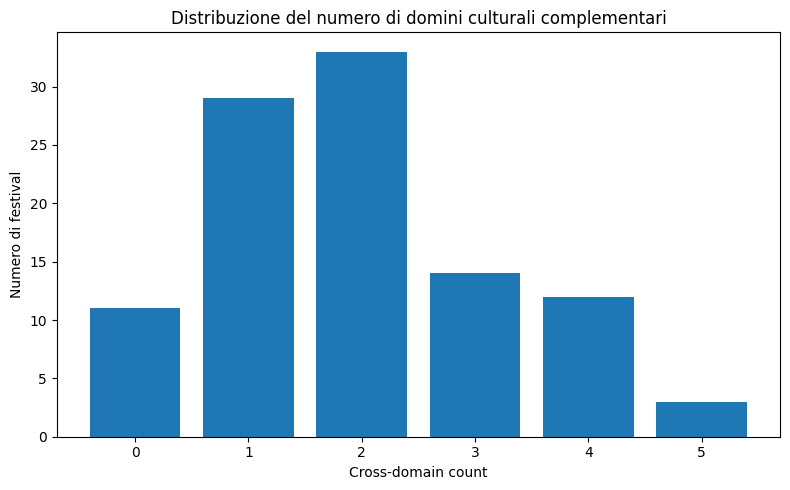

In [ ]:
# Distribuzione del cross_domain_count
cross_domain_distribution = (
    df["cross_domain_count"]
    .value_counts()
    .sort_index()
)

# Tabella con frequenze e percentuali
cross_domain_table = pd.DataFrame({
    "cross_domain_count": cross_domain_distribution.index,
    "festival": cross_domain_distribution.values,
    "percentuale": (
        cross_domain_distribution.values / len(df) * 100
    ).round(1)
})

display(cross_domain_table)


# Grafico
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    cross_domain_table["cross_domain_count"],
    cross_domain_table["festival"]
)

plt.xlabel("Cross-domain count")
plt.ylabel("Numero di festival")
plt.title("Distribuzione del numero di domini culturali complementari")
plt.xticks(cross_domain_table["cross_domain_count"])

plt.tight_layout()
plt.show()

In [ ]:
#international orientation score
df["international_orientation_score"] = (
    df["has_international_call"].fillna(0)
    + df["has_international_partners"].fillna(0)
)

display(
    df[
        [
            "festival_name",
            "has_international_call",
            "has_international_partners",
            "international_orientation_score"
        ]
    ].head(10)
)

,festival_name,has_international_call,has_international_partners,international_orientation_score
0,ANALOGICA,1.0,1.0,2.0
1,Milano Centrale Festival,0.0,0.0,0.0
2,Fano Centrale Festival,1.0,0.0,1.0
3,Festival della Fotografia Etica,1.0,1.0,2.0
4,Siena Awards Photo Festival,1.0,1.0,2.0
5,Yeast Photo Festival,1.0,1.0,2.0
6,Grenze - Arsenali Fotografici,1.0,1.0,2.0
7,SI Fest - Savignano Immagini Festival,1.0,0.0,1.0
8,ZeroNegativo,0.0,0.0,0.0
9,Festival Ubiqua,0.0,0.0,0.0


In [ ]:
international_score_counts = (
    df["international_orientation_score"]
    .value_counts()
    .sort_index()
)

display(international_score_counts)

,count
international_orientation_score,
0.0,40
1.0,36
2.0,26


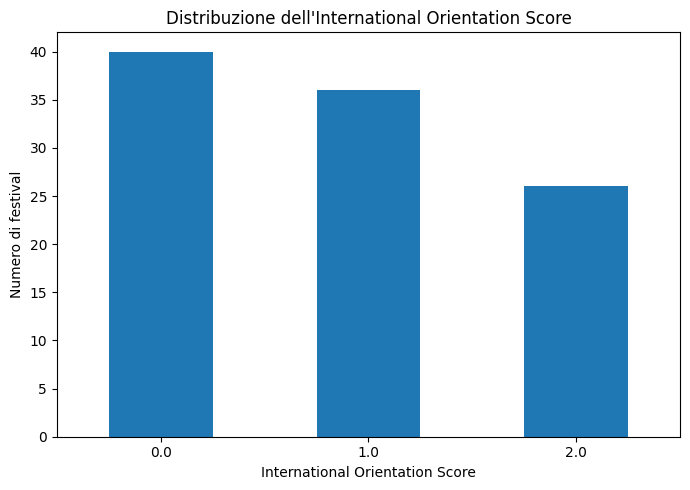

In [ ]:
plt.figure(figsize=(7, 5))

international_score_counts.plot(
    kind="bar"
)

plt.xlabel("International Orientation Score")
plt.ylabel("Numero di festival")
plt.title("Distribuzione dell'International Orientation Score")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

##4.2 Relazione tra longevità e presenza digitale

In [ ]:
df[
    ["festival_longevity", "digital_presence_score"]
].notna().all(axis=1).sum()

np.int64(98)

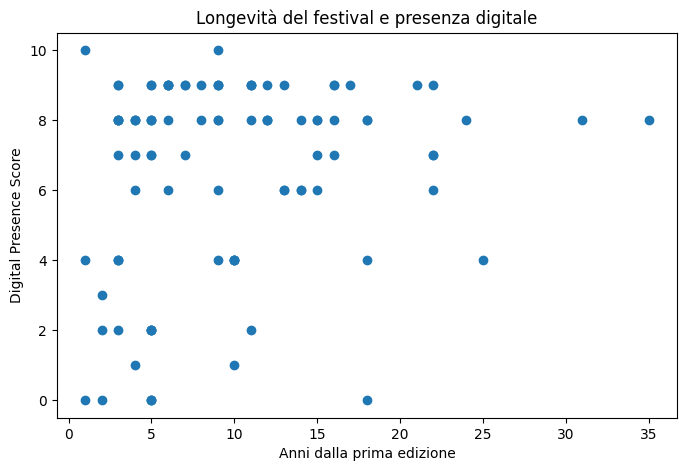

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["festival_longevity"],
    df["digital_presence_score"]
)

plt.xlabel("Anni dalla prima edizione")
plt.ylabel("Digital Presence Score")
plt.title("Longevità del festival e presenza digitale")

plt.show()

In [ ]:
df_longevity_digital = df[
    [
        "festival_longevity",
        "digital_presence_score"
    ]
].dropna()

correlation = df_longevity_digital.corr(
    method="spearman"
).loc[
    "festival_longevity",
    "digital_presence_score"
]

print(
    f"Correlazione di Spearman: {correlation:.3f}"
)

Correlazione di Spearman: 0.184


### Osservazione

La correlazione di Spearman tra la longevità dei festival e il Digital Presence Score è pari a 0,184, indicando una relazione positiva debole tra le due variabili. Nel campione analizzato, quindi, la maggiore anzianità dei festival non appare associata in modo marcato a una maggiore presenza digitale.

## 4.3 Relazione tra internazionalizzazione e presenza digitale

In [ ]:
df_international_digital = df[
    [
        "international_orientation_score",
        "digital_presence_score"
    ]
].dropna()

print(
    "Festival considerati:",
    len(df_international_digital)
)

Festival considerati: 102


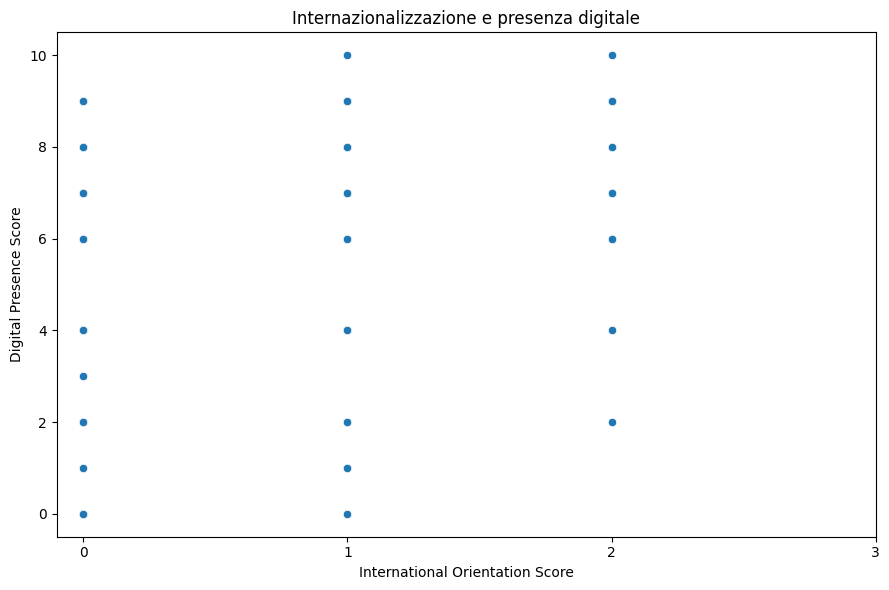

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_international_digital,
    x="international_orientation_score",
    y="digital_presence_score"
)

plt.xlabel("International Orientation Score")
plt.ylabel("Digital Presence Score")
plt.title(
    "Internazionalizzazione e presenza digitale"
)

plt.xticks([0, 1, 2, 3])

plt.tight_layout()
plt.show()

In [ ]:
correlation_international_digital = (
    df_international_digital.corr(
        method="spearman"
    ).loc[
        "international_orientation_score",
        "digital_presence_score"
    ]
)

print(
    f"Correlazione di Spearman: "
    f"{correlation_international_digital:.3f}"
)

Correlazione di Spearman: 0.451


In [ ]:
display(
    df["international_orientation_score"]
    .value_counts()
    .sort_index()
)

,count
international_orientation_score,
0.0,40
1.0,36
2.0,26


### Osservazione

La correlazione di Spearman tra l'International Orientation Score e il Digital Presence Score è pari a 0,451. Il valore indica una relazione positiva di entità moderata: nel campione analizzato, una maggiore presenza di indicatori di apertura internazionale tende ad associarsi a livelli più elevati di presenza digitale. Il risultato è interpretato in termini esplorativi e non implica una relazione causale tra le due dimensioni.

## 4.4  Relazione tra interdisciplinarità e apertura internazionale

In [ ]:
cross_domain_distribution = (
    df["cross_domain_count"]
    .value_counts()
    .sort_index()
)

display(cross_domain_distribution)

,count
cross_domain_count,
0.0,11
1.0,29
2.0,33
3.0,14
4.0,12
5.0,3


In [ ]:
df_domains_international = df[
    [
        "cross_domain_count",
        "international_orientation_score"
    ]
].dropna()

print(
    "Festival considerati:",
    len(df_domains_international)
)

Festival considerati: 102


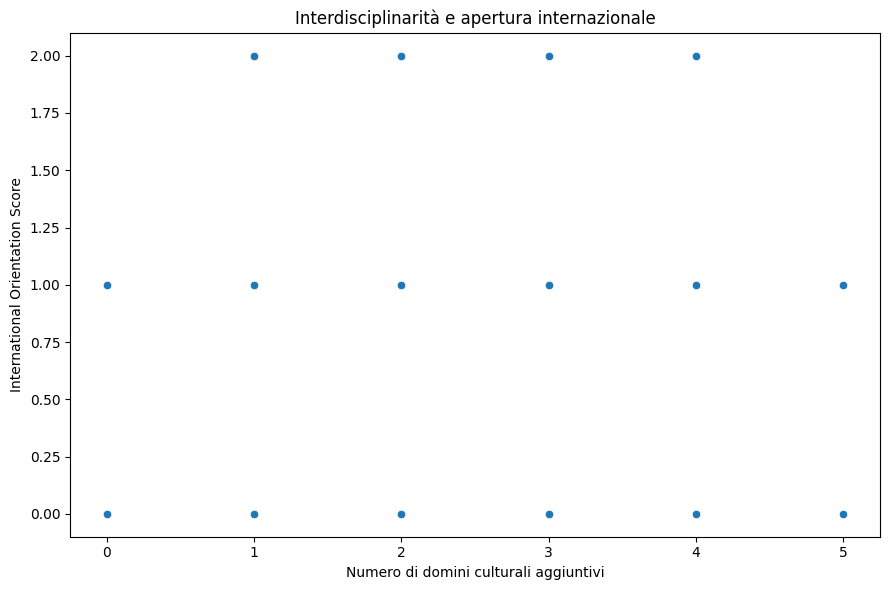

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_domains_international,
    x="cross_domain_count",
    y="international_orientation_score"
)

plt.xlabel("Numero di domini culturali aggiuntivi")
plt.ylabel("International Orientation Score")
plt.title(
    "Interdisciplinarità e apertura internazionale"
)

plt.tight_layout()
plt.show()

In [ ]:
correlation_domains_international = (
    df_domains_international.corr(
        method="spearman"
    ).loc[
        "cross_domain_count",
        "international_orientation_score"
    ]
)

print(
    f"Correlazione di Spearman: "
    f"{correlation_domains_international:.3f}"
)

Correlazione di Spearman: 0.176


### Osservazione

La correlazione di Spearman tra il numero di domini culturali aggiuntivi e l'International Orientation Score è pari a 0,176, indicando una relazione positiva molto debole. Nel campione analizzato, pertanto, una maggiore diversificazione dei domini culturali non appare associata in modo marcato a una maggiore apertura internazionale.

## 4.5 Relazione tra tipologia di organizzatore e presenza digitale

In [ ]:
display(
    df["organizer_type"].value_counts(dropna=False)
)

,count
organizer_type,
non-profit,86
private,7
mixed,6
public,3


In [ ]:
organizer_digital = (
    df.groupby(
        "organizer_type",
        dropna=False
    )["digital_presence_score"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .sort_values(
        "mean",
        ascending=False
    )
)

display(organizer_digital)

,count,mean,median
organizer_type,,,
private,7,6.857143,8.0
non-profit,86,6.453488,8.0
mixed,6,5.833333,7.5
public,3,3.333333,2.0


### Osservazione

Il confronto tra tipologia di organizzatore e Digital Presence Score mostra valori medi differenti tra le categorie. I festival organizzati da soggetti privati presentano il punteggio medio più elevato (6,86), seguiti dalle organizzazioni non-profit (6,45) e dalle forme miste (5,83). I festival classificati come pubblici presentano invece un valore medio inferiore (3,33).

Il risultato deve tuttavia essere interpretato alla luce della distribuzione fortemente sbilanciata del campione: la categoria non-profit comprende 86 festival, mentre le categorie private, mixed e public ne comprendono rispettivamente 7, 6 e 3. Pertanto, il confronto ha carattere esclusivamente esplorativo e non consente di generalizzare le differenze osservate tra le tipologie organizzative.

## 4.6 Relazione tra tipologia di organizzatore e apertura internazionale

In [ ]:

organizer_international = (
    df.groupby(
        "organizer_type",
        dropna=False
    )["international_orientation_score"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .sort_values(
        "mean",
        ascending=False
    )
)

display(organizer_international)

,count,mean,median
organizer_type,,,
mixed,6,1.000000,1.0
non-profit,86,0.883721,1.0
private,7,0.714286,0.0
public,3,0.333333,0.0


In [ ]:
organizer_international_distribution = pd.crosstab(
    df["organizer_type"],
    df["international_orientation_score"]
)

display(organizer_international_distribution)

international_orientation_score,0.0,1.0,2.0
organizer_type,,,
mixed,2,2,2
non-profit,32,32,22
private,4,1,2
public,2,1,0


### Osservazione

Il confronto tra tipologia di organizzatore e International Orientation Score mostra una maggiore presenza media di indicatori di apertura internazionale tra i festival organizzati da soggetti mixed (1,00) e non-profit (0,88), rispetto ai soggetti privati (0,71) e pubblici (0,33).

La distribuzione dei valori mostra inoltre che, tra i festival non-profit, gli indicatori di apertura internazionale risultano maggiormente distribuiti tra i diversi livelli dello score, mentre nessuno dei tre festival classificati come pubblici raggiunge il valore massimo. Il risultato deve tuttavia essere interpretato in chiave esplorativa, considerando la forte diversa numerosità delle categorie organizzative.

## 4.7 Relazione tra apertura internazionale e lingue del sito web

In [ ]:
website_international = pd.crosstab(
    df["website_languages"],
    df["international_orientation_score"]
)

display(website_international)

international_orientation_score,0.0,1.0,2.0
website_languages,,,
IT_EN,7,12,19
IT_ONLY,33,23,5
MULTI,0,1,2


In [ ]:
website_international_percent = (
    pd.crosstab(
        df["website_languages"],
        df["international_orientation_score"],
        normalize="index"
    )
    .mul(100)
    .round(1)
)

display(website_international_percent)


international_orientation_score,0.0,1.0,2.0
website_languages,,,
IT_EN,18.4,31.6,50.0
IT_ONLY,54.1,37.7,8.2
MULTI,0.0,33.3,66.7


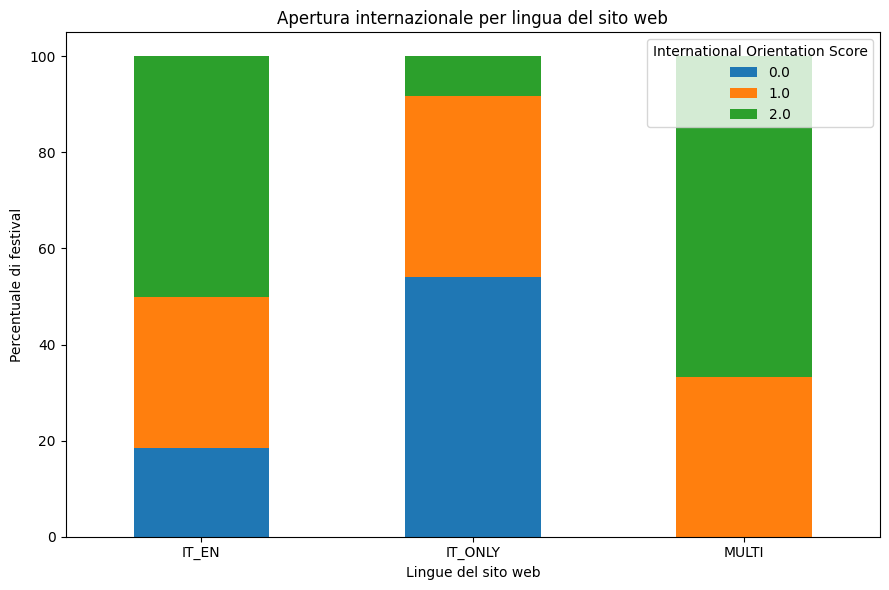

In [ ]:
website_international_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 6)
)

plt.xlabel("Lingue del sito web")
plt.ylabel("Percentuale di festival")
plt.title(
    "Apertura internazionale per lingua del sito web"
)

plt.xticks(rotation=0)
plt.legend(
    title="International Orientation Score"
)

plt.tight_layout()
plt.show()

### Osservazione

La distribuzione dell'International Orientation Score varia in modo evidente in relazione alle lingue utilizzate nei siti web. Tra i festival con siti esclusivamente in italiano (IT_ONLY), il 54,1% presenta un International Orientation Score pari a 0 e solo l'8,2% raggiunge il valore massimo di 2. Al contrario, tra i festival con siti in italiano e inglese (IT_EN), il 50,0% raggiunge il punteggio massimo e il 18,4% presenta un punteggio pari a 0.

La categoria MULTI mostra una distribuzione ancora più orientata verso il valore massimo, con il 66,7% dei festival a score 2; tuttavia, il gruppo comprende soltanto tre osservazioni e non consente interpretazioni generalizzabili.

Nel campione analizzato emerge quindi un'associazione descrittiva tra maggiore apertura internazionale e presenza di contenuti web in più lingue, particolarmente evidente nel passaggio dalla categoria IT_ONLY alla categoria IT_EN.

## 4.8 Relazione tra presenza digitale e lingue del sito web

In [ ]:
website_digital = (
    df.groupby(
        "website_languages",
        dropna=False
    )["digital_presence_score"]
    .agg(
        count="count",
        mean="mean",
        median="median"
    )
    .sort_values(
        "mean",
        ascending=False
    )
)

display(website_digital)

,count,mean,median
website_languages,,,
MULTI,3,8.000000,10.0
IT_EN,38,7.684211,9.0
IT_ONLY,61,5.442623,6.0


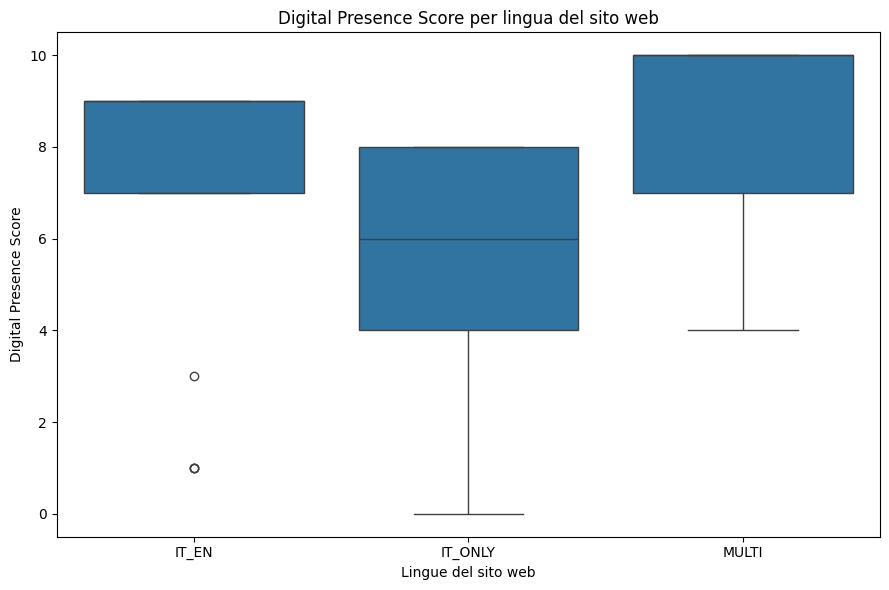

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="website_languages",
    y="digital_presence_score"
)

plt.xlabel("Lingue del sito web")
plt.ylabel("Digital Presence Score")
plt.title(
    "Digital Presence Score per lingua del sito web"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

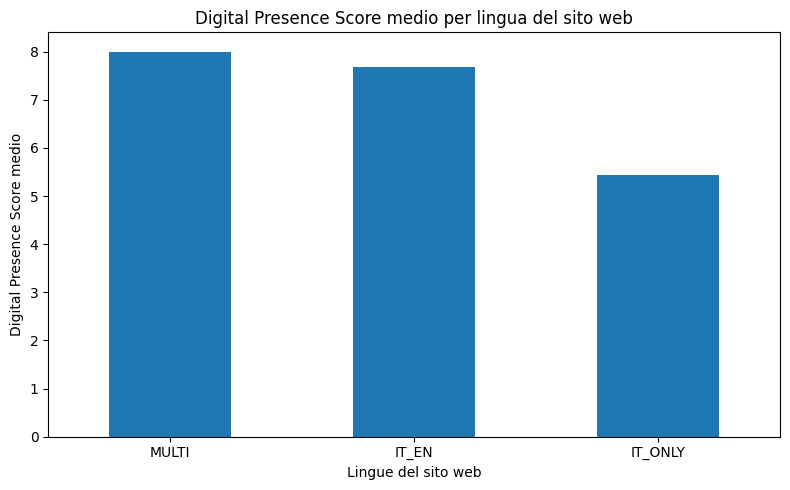

In [ ]:
website_digital["mean"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Lingue del sito web")
plt.ylabel("Digital Presence Score medio")
plt.title(
    "Digital Presence Score medio per lingua del sito web"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
display(
    website_digital[
        ["count", "mean", "median"]
    ].round(2)
)

,count,mean,median
website_languages,,,
MULTI,3,8.00,10.0
IT_EN,38,7.68,9.0
IT_ONLY,61,5.44,6.0


Nel campione analizzato emerge un'associazione descrittiva tra maggiore articolazione linguistica dei siti web e livelli più elevati di presenza digitale. I festival con siti esclusivamente in italiano presentano un Digital Presence Score medio pari a 5,44, mentre il valore sale a 7,68 tra quelli che utilizzano italiano e inglese. La categoria MULTI presenta un valore medio ancora superiore (8,00), ma comprende soltanto tre festival.

# 5. Sintesi dei risultati dell'analisi

In [ ]:
# ==========================================================
# SINTESI GENERALE DEL DATASET
# ==========================================================

summary_dataset = pd.DataFrame({
    "metrica": [
        "Numero di festival",
        "Digital Presence Score medio",
        "Digital Presence Score mediano",
        "International Orientation Score medio",
        "International Orientation Score mediano",
        "Cross-domain count medio",
        "Cross-domain count mediano"
    ],
    "valore": [
        len(df),
        df["digital_presence_score"].mean(),
        df["digital_presence_score"].median(),
        df["international_orientation_score"].mean(),
        df["international_orientation_score"].median(),
        df["cross_domain_count"].mean(),
        df["cross_domain_count"].median()
    ]
})

summary_dataset["valore"] = summary_dataset["valore"].round(2)

display(summary_dataset)

,metrica,valore
0,Numero di festival,102.00
1,Digital Presence Score medio,6.35
2,Digital Presence Score mediano,8.00
3,International Orientation Score medio,0.86
4,International Orientation Score mediano,1.00
5,Cross-domain count medio,1.96
6,Cross-domain count mediano,2.00


In [ ]:
# ==========================================================
# RIEPILOGO DELLE CORRELAZIONI
# ==========================================================

summary_correlations = pd.DataFrame({
    "relazione": [
        "Festival longevity – Digital Presence Score",
        "International Orientation Score – Digital Presence Score",
        "Cross-domain count – International Orientation Score"
    ],
    "spearman_rho": [
        0.184,
        0.451,
        0.176
    ],
    "interpretazione": [
        "Relazione positiva molto debole",
        "Relazione positiva moderata",
        "Relazione positiva molto debole"
    ]
})

display(summary_correlations)

,relazione,spearman_rho,interpretazione
0,Festival longevity – Digital Presence Score,0.184,Relazione positiva molto debole
1,International Orientation Score – Digital Pres...,0.451,Relazione positiva moderata
2,Cross-domain count – International Orientation...,0.176,Relazione positiva molto debole


In [ ]:
# ==========================================================
# ORGANIZER TYPE
# ==========================================================

summary_organizer = (
    df.groupby("organizer_type")[
        [
            "digital_presence_score",
            "international_orientation_score"
        ]
    ]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(summary_organizer)

digital_presence_score               \
                                count  mean median   
organizer_type                                       
mixed                               6  5.83    7.5   
non-profit                         86  6.45    8.0   
private                             7  6.86    8.0   
public                              3  3.33    2.0   

               international_orientation_score               
                                         count  mean median  
organizer_type                                               
mixed                                        6  1.00    1.0  
non-profit                                  86  0.88    1.0  
private                                      7  0.71    0.0  
public                                       3  0.33    0.0

In [ ]:
# ==========================================================
# WEBSITE LANGUAGES – INTERNATIONAL ORIENTATION
# ==========================================================

summary_languages = pd.crosstab(
    df["website_languages"],
    df["international_orientation_score"],
    normalize="index"
).mul(100).round(1)

display(summary_languages)

international_orientation_score,0.0,1.0,2.0
website_languages,,,
IT_EN,18.4,31.6,50.0
IT_ONLY,54.1,37.7,8.2
MULTI,0.0,33.3,66.7


In [ ]:
# ==========================================================
# INDICATORI PRINCIPALI DEL CAMPIONE
# ==========================================================

indicatori_principali = pd.DataFrame({
    "indicatore": [
        "Digital Presence Score",
        "International Orientation Score",
        "Cross-domain count",
        "Festival longevity"
    ],
    "media": [
        df["digital_presence_score"].mean(),
        df["international_orientation_score"].mean(),
        df["cross_domain_count"].mean(),
        df["festival_longevity"].mean()
    ],
    "mediana": [
        df["digital_presence_score"].median(),
        df["international_orientation_score"].median(),
        df["cross_domain_count"].median(),
        df["festival_longevity"].median()
    ]
}).round(2)

display(indicatori_principali)

,indicatore,media,mediana
0,Digital Presence Score,6.35,8.0
1,International Orientation Score,0.86,1.0
2,Cross-domain count,1.96,2.0
3,Festival longevity,9.71,9.0


In [ ]:
# ==========================================================
# SINTESI DELLE PRINCIPALI RELAZIONI
# ==========================================================

print("PRINCIPALI RISULTATI DELL'ANALISI ESPLORATIVA")
print("=" * 55)

print(
    "Longevità ↔ Digital Presence: "
    "ρ = 0.184 (relazione molto debole)"
)

print(
    "International Orientation ↔ Digital Presence: "
    "ρ = 0.451 (relazione moderata)"
)

print(
    "Cross-domain ↔ International Orientation: "
    "ρ = 0.176 (relazione molto debole)"
)

print(
    "Organizer ↔ Digital Presence: "
    "differenze descrittive tra le categorie"
)

print(
    "Organizer ↔ International Orientation: "
    "differenze descrittive tra le categorie"
)

print(
    "Website Languages ↔ International Orientation: "
    "associazione descrittiva evidente, soprattutto "
    "tra IT_ONLY e IT_EN"
)

print(
    "Website Languages ↔ Digital Presence: "
    "differenze descrittive evidenti, con valori "
    "più elevati per IT_EN e MULTI rispetto a IT_ONLY"
)

PRINCIPALI RISULTATI DELL'ANALISI ESPLORATIVA
Longevità ↔ Digital Presence: ρ = 0.184 (relazione molto debole)
International Orientation ↔ Digital Presence: ρ = 0.451 (relazione moderata)
Cross-domain ↔ International Orientation: ρ = 0.176 (relazione molto debole)
Organizer ↔ Digital Presence: differenze descrittive tra le categorie
Organizer ↔ International Orientation: differenze descrittive tra le categorie
Website Languages ↔ International Orientation: associazione descrittiva evidente, soprattutto tra IT_ONLY e IT_EN
Website Languages ↔ Digital Presence: differenze descrittive evidenti, con valori più elevati per IT_EN e MULTI rispetto a IT_ONLY
